# Data Analysis and Corelating between Data Sets
this notebook aims to:
1. Find suitable pairs of coral species and hand images, bases on similarities between text descriptions of shape characteristics of each data point. 
2. Sample possible coral species for a list of reefs based on habitat descriptions and coral reef benthic and geomorphic class

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

# Set random seed for reproducibility
np.random.seed(42)

# Set paths
DATA_DIR = Path('./scrapped_data')
CORAL_SPECIES_FILE = DATA_DIR / 'coral_species.csv'
HAND_IMAGES_FILE = DATA_DIR / 'hand_image_annotations.csv'
REEF_GEOJSON_FILE = DATA_DIR / 'coral_reef_combined.geojson'
OUTPUT_DIR = Path('./MLoutput')
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Find Coral Species and Hand Image Pairs

**Approach:**
1. Load coral species characteristics from CSV
2. Load hand image annotations (when available)
3. Use TF-IDF vectorization to convert text descriptions to numerical vectors
4. Calculate cosine similarity between all coral-hand image pairs
5. Find best matches based on similarity scores
6. Save results to CSV and visualize with similarity matrices and distributions

In [3]:
# Load coral species data
coral_df = pd.read_csv(CORAL_SPECIES_FILE)

print("Coral Species Data Loaded:")
print(f"Shape: {coral_df.shape}")
print(f"\nColumns: {coral_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(coral_df.head())
print(f"\nData types:\n{coral_df.dtypes}")

# Combine relevant text fields for vectorization
# Combining characters, color, habitat, and abundance into a comprehensive description
coral_df['combined_description'] = (
    coral_df['characters'].fillna('') + ' ' + 
    coral_df['color'].fillna('')
).str.replace(r'\s+', ' ', regex=True).str.strip()

print(f"\nCombined description created. Sample:\n{coral_df['combined_description'].iloc[0][:200]}...")

Coral Species Data Loaded:
Shape: (831, 7)

Columns: ['species', 'url', 'characters', 'color', 'habitat', 'abundance', 'image_url']

First few rows:
                    species  \
0   Acanthastrea bowerbanki   
1       Acanthastrea brevis   
2     Acanthastrea echinata   
3  Acanthastrea faviaformis   
4   Acanthastrea hemprichii   

                                                 url  \
0  https://www.coralsoftheworld.org/species_facts...   
1  https://www.coralsoftheworld.org/species_facts...   
2  https://www.coralsoftheworld.org/species_facts...   
3  https://www.coralsoftheworld.org/species_facts...   
4  https://www.coralsoftheworld.org/species_facts...   

                                          characters  \
0  Characters:Colonies are encrusting and usually...   
1  Characters:Colonies are mostly submassive. Cor...   
2  Characters:Colonies are encrusting to massive ...   
3  Characters:Colonies are encrusting to massive,...   
4  Characters:Colonies are encrusting to massiv

In [4]:
# Load hand image descriptions
# Note: This file should follow the structure: 'filename' and 'annotation' columns

# Check if hand images descriptions file exists
if HAND_IMAGES_FILE.exists():
    hand_df = pd.read_csv(HAND_IMAGES_FILE)
    print("Hand Images Data Loaded:")
    print(f"Shape: {hand_df.shape}")
    print(hand_df.head())
else:
    print(f"⚠️ Hand images descriptions file not found at {HAND_IMAGES_FILE}")
    print("Creating sample data for demonstration purposes...")
    # Create sample hand image data for demonstration
    hand_df = pd.DataFrame({
        'filename': ['hand_image_001.jpg', 'hand_image_002.jpg', 'hand_image_003.jpg',
                     'hand_image_004.jpg', 'hand_image_005.jpg'],
        'annotation': [
            'elongate pointed fingers branching structure with textured surface',
            'compact rounded form with protruding knobs uniform appearance',
            'cerioid corallites thin walls spiky appearance compact arrangement',
            'massive hemispherical shape thick tissue fleshy mantle blue grey',
            'encrusting flat growth thin branches delicate lattice network'
        ]
    })
    print("\nSample Hand Images Data (for demonstration):")
    print(hand_df)
    # Save sample for reference
    # hand_df.to_csv(HAND_IMAGES_FILE, index=False)

print(f"\nHand images data ready: {hand_df.shape[0]} images")

Hand Images Data Loaded:
Shape: (271, 2)
              filename                                         annotation
0  hand_image_0001.jpg  Right hand in pronated orientation with dorsal...
1  hand_image_0003.jpg  Right hand in supinated orientation with palm ...
2  hand_image_0004.jpg  Right hand in pronated position extended horiz...
3  hand_image_0005.jpg  Right hand presented in supinated position wit...
4  hand_image_0006.jpg  Right hand in supinated position with forearm ...

Hand images data ready: 271 images


In [5]:
# Text Vectorization using TF-IDF
print("=" * 60)
print("Text Vectorization using TF-IDF")
print("=" * 60)

# Combine all texts for vectorization
all_texts = pd.concat([
    coral_df['combined_description'],
    hand_df['annotation']
], ignore_index=True)

# Initialize and fit TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=100,
    min_df=1,
    max_df=0.9,
    ngram_range=(1, 2),
    stop_words='english'
)

# Fit vectorizer on all texts
vectorizer.fit(all_texts)

# Transform coral and hand descriptions
coral_vectors = vectorizer.transform(coral_df['combined_description'])
hand_vectors = vectorizer.transform(hand_df['annotation'])

print(f"Vectorizer fitted with vocabulary size: {len(vectorizer.get_feature_names_out())}")
print(f"Coral vectors shape: {coral_vectors.shape}")
print(f"Hand vectors shape: {hand_vectors.shape}")

Text Vectorization using TF-IDF
Vectorizer fitted with vocabulary size: 100
Coral vectors shape: (831, 100)
Hand vectors shape: (271, 100)


In [6]:
# Calculate Cosine Similarity Matrix
print("\n" + "=" * 60)
print("Calculating Cosine Similarity")
print("=" * 60)

# Calculate similarity matrix between hand images and coral species
similarity_matrix = cosine_similarity(hand_vectors, coral_vectors)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Similarity scores range: [{similarity_matrix.min():.4f}, {similarity_matrix.max():.4f}]")

# Display similarity matrix as DataFrame for better visualization
sim_df_display = pd.DataFrame(
    similarity_matrix,
    index=hand_df['filename'].values,
    columns=coral_df['species'].values
)

print("\nSimilarity Matrix (first 5 coral species):")
print(sim_df_display.iloc[:, :5])


Calculating Cosine Similarity
Similarity matrix shape: (271, 831)
Similarity scores range: [0.0000, 0.3075]

Similarity Matrix (first 5 coral species):
                     Acanthastrea bowerbanki  Acanthastrea brevis  \
hand_image_0001.jpg                      0.0                  0.0   
hand_image_0003.jpg                      0.0                  0.0   
hand_image_0004.jpg                      0.0                  0.0   
hand_image_0005.jpg                      0.0                  0.0   
hand_image_0006.jpg                      0.0                  0.0   
...                                      ...                  ...   
hand_image_0277.jpg                      0.0                  0.0   
hand_image_0278.jpg                      0.0                  0.0   
hand_image_0279.jpg                      0.0                  0.0   
hand_image_0280.jpg                      0.0                  0.0   
hand_image_0281.jpg                      0.0                  0.0   

                  

In [7]:
# Find Best Matches
print("\n" + "=" * 60)
print("Finding Best Matches")
print("=" * 60)

# For each coral species, find the best matching hand image
pairs = []
match_details = []

for coral_idx, coral_species in enumerate(coral_df['species'].values):
    # Get similarity scores for this coral species against all hand images
    scores = similarity_matrix[:, coral_idx]
    
    # Find best match
    best_hand_idx = np.argmax(scores)
    best_hand_file = hand_df['filename'].iloc[best_hand_idx]
    best_score = scores[best_hand_idx]
    
    # Store pair
    pairs.append({
        'coral_species': coral_species,
        'hand_image_filename': best_hand_file,
        'similarity_score': best_score
    })
    
    # Get top 5 matches for detailed analysis
    top_5_indices = np.argsort(scores)[-5:][::-1]
    for rank, idx in enumerate(top_5_indices, 1):
        match_details.append({
            'coral_species': coral_species,
            'rank': rank,
            'hand_image': hand_df['filename'].iloc[idx],
            'similarity_score': scores[idx]
        })

# Create DataFrames
pairs_df = pd.DataFrame(pairs)
match_details_df = pd.DataFrame(match_details)

print("\nBest Matched Pairs (first 10 coral species):")
print(pairs_df.head(10))

print(f"\nTotal pairs found: {len(pairs_df)}")
print(f"\nBest match scores statistics:")
print(pairs_df['similarity_score'].describe())

print("\nTop 5 Hand Images for Each Coral Species (sample - first 6 species):")
for coral in coral_df['species'].unique()[:6]:
    coral_matches = match_details_df[match_details_df['coral_species'] == coral]
    print(f"\n  {coral}:")
    for _, row in coral_matches.head(3).iterrows():
        print(f"    Rank {row['rank']}: {row['hand_image'][:40]:<40} Score: {row['similarity_score']:.4f}")

# Save pairs to CSV
output_file = OUTPUT_DIR / 'coral_hand_image_pairs.csv'
pairs_df.to_csv(output_file, index=False)
print(f"\n✓ Pairs saved to {output_file}")



Finding Best Matches

Best Matched Pairs (first 10 coral species):
                coral_species  hand_image_filename  similarity_score
0     Acanthastrea bowerbanki  hand_image_0215.jpg          0.088951
1         Acanthastrea brevis  hand_image_0222.jpg          0.082465
2       Acanthastrea echinata  hand_image_0222.jpg          0.101990
3    Acanthastrea faviaformis  hand_image_0279.jpg          0.089619
4     Acanthastrea hemprichii  hand_image_0107.jpg          0.017898
5         Acanthastrea hillae  hand_image_0135.jpg          0.066044
6  Acanthastrea ishigakiensis  hand_image_0063.jpg          0.103374
7   Acanthastrea lordhowensis  hand_image_0053.jpg          0.070141
8      Acanthastrea regularis  hand_image_0242.jpg          0.054559
9   Acanthastrea rotundoflora  hand_image_0028.jpg          0.121391

Total pairs found: 831

Best match scores statistics:
count    831.000000
mean       0.112929
std        0.044875
min        0.000000
25%        0.082487
50%        0.11111

### Visualizations for Step 1

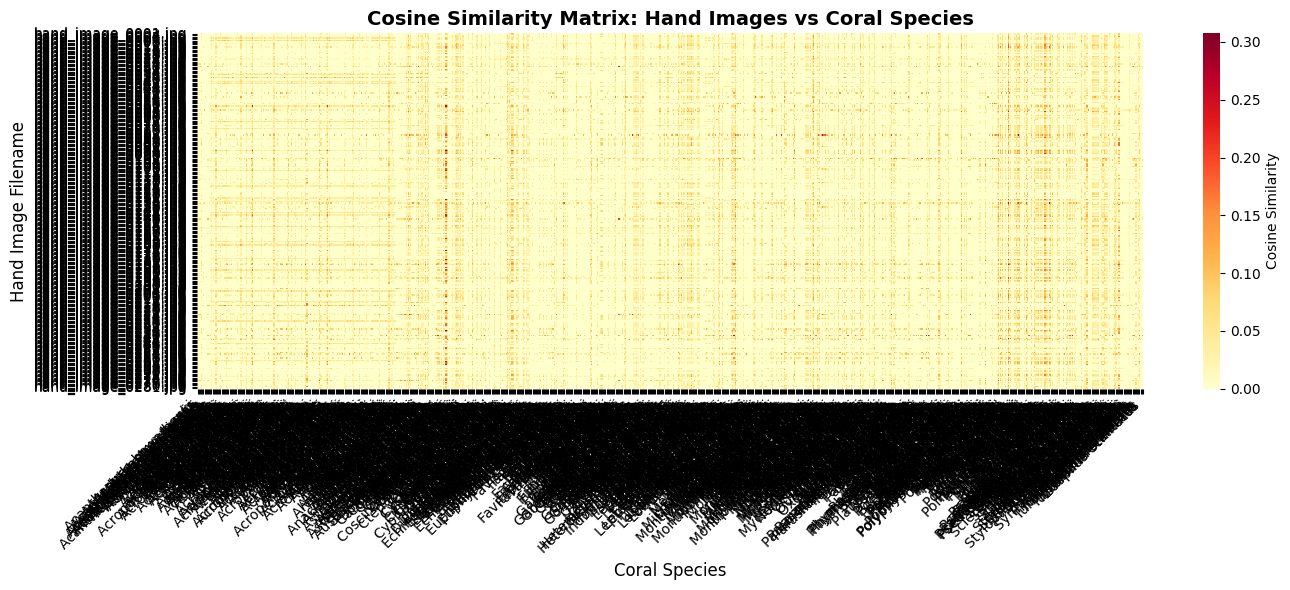

✓ Similarity matrix heatmap saved


In [7]:
# Visualization 1: Similarity Matrix Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(similarity_matrix, 
            cmap='YlOrRd', 
            xticklabels=coral_df['species'].values,
            yticklabels=hand_df['filename'].values,
            cbar_kws={'label': 'Cosine Similarity'},
            ax=ax)
plt.title('Cosine Similarity Matrix: Hand Images vs Coral Species', fontsize=14, fontweight='bold')
plt.xlabel('Coral Species', fontsize=12)
plt.ylabel('Hand Image Filename', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'similarity_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Similarity matrix heatmap saved")

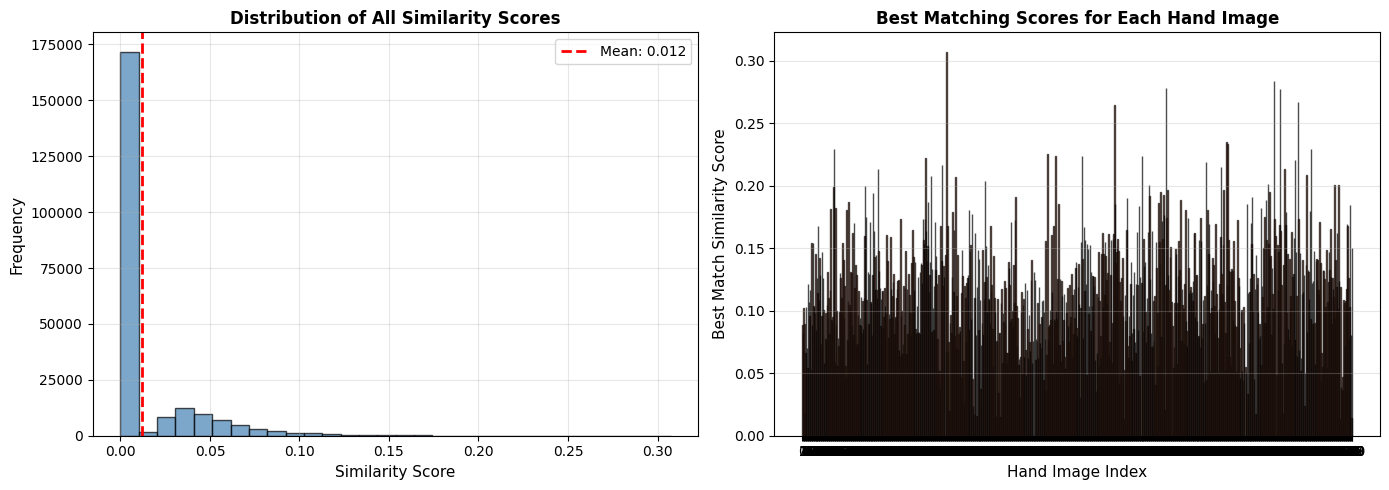

✓ Similarity distribution plots saved


In [8]:
# Visualization 2: Distribution of Similarity Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all similarity scores
all_scores = similarity_matrix.flatten()
axes[0].hist(all_scores, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(all_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {all_scores.mean():.3f}')
axes[0].set_xlabel('Similarity Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of All Similarity Scores', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Best match scores for each hand image
best_scores = pairs_df['similarity_score'].values
axes[1].bar(range(len(best_scores)), best_scores, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Hand Image Index', fontsize=11)
axes[1].set_ylabel('Best Match Similarity Score', fontsize=11)
axes[1].set_title('Best Matching Scores for Each Hand Image', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(best_scores)))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'similarity_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Similarity distribution plots saved")

## Alternative Matching Methods (Semantic Similarity)

Due to limited vocabulary overlap between hand image annotations and coral descriptions, we explore semantic-based matching methods that capture meaning beyond exact word matches.

**Methods to compare:**
1. **Current TF-IDF**: Based on exact vocabulary overlap (baseline)
2. **Semantic Embeddings**: Using pre-trained sentence embeddings (captures meaning)
3. **Hybrid Approach**: Combination of multiple similarity metrics


In [8]:
# Alternative Method 1: Semantic Embeddings (Universal Sentence Encoder)
print("\n" + "=" * 70)
print("ALTERNATIVE METHOD 1: Semantic Embeddings (Sentence Transformers)")
print("=" * 70)

try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('all-MiniLM-L6-v2')
    print("✓ Sentence Transformers model loaded successfully")
    
    # Encode coral and hand descriptions
    print("\nEncoding coral descriptions...")
    coral_embeddings = model.encode(coral_df['combined_description'].values, show_progress_bar=True)
    
    print("Encoding hand image annotations...")
    hand_embeddings = model.encode(hand_df['annotation'].values, show_progress_bar=True)
    
    # Calculate semantic similarity using cosine similarity
    semantic_similarity = cosine_similarity(hand_embeddings, coral_embeddings)
    
    print(f"\nSemantic similarity matrix shape: {semantic_similarity.shape}")
    print(f"Semantic similarity range: [{semantic_similarity.min():.4f}, {semantic_similarity.max():.4f}]")
    
    # Find best matches using semantic method
    pairs_semantic = []
    for coral_idx, coral_species in enumerate(coral_df['species'].values):
        scores = semantic_similarity[:, coral_idx]
        best_hand_idx = np.argmax(scores)
        best_hand_file = hand_df['filename'].iloc[best_hand_idx]
        best_score = scores[best_hand_idx]
        
        pairs_semantic.append({
            'coral_species': coral_species,
            'hand_image_filename': best_hand_file,
            'semantic_similarity_score': best_score
        })
    
    pairs_semantic_df = pd.DataFrame(pairs_semantic)
    
    print("\nBest Matched Pairs (Semantic Method - first 10):")
    print(pairs_semantic_df.head(10))
    print(f"\nSemantic similarity scores statistics:")
    print(pairs_semantic_df['semantic_similarity_score'].describe())
    
    semantic_method_available = True
    
except ImportError:
    print("⚠️ sentence-transformers not installed. Installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sentence-transformers", "-q"])
    print("Installation complete. Please re-run this cell.")
    semantic_method_available = False



ALTERNATIVE METHOD 1: Semantic Embeddings (Sentence Transformers)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Sentence Transformers model loaded successfully

Encoding coral descriptions...


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Encoding hand image annotations...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]


Semantic similarity matrix shape: (271, 831)
Semantic similarity range: [-0.1303, 0.4488]

Best Matched Pairs (Semantic Method - first 10):
                coral_species  hand_image_filename  semantic_similarity_score
0     Acanthastrea bowerbanki  hand_image_0047.jpg                   0.326684
1         Acanthastrea brevis  hand_image_0047.jpg                   0.304753
2       Acanthastrea echinata  hand_image_0047.jpg                   0.336764
3    Acanthastrea faviaformis  hand_image_0047.jpg                   0.280133
4     Acanthastrea hemprichii  hand_image_0047.jpg                   0.321817
5         Acanthastrea hillae  hand_image_0047.jpg                   0.362080
6  Acanthastrea ishigakiensis  hand_image_0278.jpg                   0.292198
7   Acanthastrea lordhowensis  hand_image_0047.jpg                   0.310893
8      Acanthastrea regularis  hand_image_0278.jpg                   0.331292
9   Acanthastrea rotundoflora  hand_image_0047.jpg                   0.336816



In [9]:
# Alternative Method 2: Hybrid Similarity (Combining TF-IDF + Semantic)
print("\n" + "=" * 70)
print("ALTERNATIVE METHOD 2: Hybrid Similarity (TF-IDF + Semantic Embeddings)")
print("=" * 70)

if semantic_method_available:
    # Normalize both matrices to 0-1 range
    tfidf_normalized = (similarity_matrix - similarity_matrix.min()) / (similarity_matrix.max() - similarity_matrix.min())
    semantic_normalized = (semantic_similarity - semantic_similarity.min()) / (semantic_similarity.max() - semantic_similarity.min())
    
    # Combine with weights: 40% semantic, 60% TF-IDF (or experiment with weights)
    hybrid_similarity = 0.6 * semantic_normalized + 0.4 * tfidf_normalized
    
    print(f"Hybrid similarity matrix shape: {hybrid_similarity.shape}")
    print(f"Hybrid similarity range: [{hybrid_similarity.min():.4f}, {hybrid_similarity.max():.4f}]")
    
    # Find best matches using hybrid method
    pairs_hybrid = []
    for coral_idx, coral_species in enumerate(coral_df['species'].values):
        scores = hybrid_similarity[:, coral_idx]
        best_hand_idx = np.argmax(scores)
        best_hand_file = hand_df['filename'].iloc[best_hand_idx]
        best_score = scores[best_hand_idx]
        
        # Get component scores for analysis
        tfidf_score = tfidf_normalized[best_hand_idx, coral_idx]
        semantic_score = semantic_normalized[best_hand_idx, coral_idx]
        
        pairs_hybrid.append({
            'coral_species': coral_species,
            'hand_image_filename': best_hand_file,
            'hybrid_similarity_score': best_score,
            'tfidf_component': tfidf_score,
            'semantic_component': semantic_score
        })
    
    pairs_hybrid_df = pd.DataFrame(pairs_hybrid)
    
    print("\nBest Matched Pairs (Hybrid Method - first 10):")
    print(pairs_hybrid_df.head(10))
    print(f"\nHybrid similarity scores statistics:")
    print(pairs_hybrid_df['hybrid_similarity_score'].describe())
else:
    print("Semantic method not available. Skipping hybrid method.")



ALTERNATIVE METHOD 2: Hybrid Similarity (TF-IDF + Semantic Embeddings)
Hybrid similarity matrix shape: (271, 831)
Hybrid similarity range: [0.0000, 0.7530]

Best Matched Pairs (Hybrid Method - first 10):
                coral_species  hand_image_filename  hybrid_similarity_score  \
0     Acanthastrea bowerbanki  hand_image_0047.jpg                 0.473435   
1         Acanthastrea brevis  hand_image_0047.jpg                 0.450714   
2       Acanthastrea echinata  hand_image_0047.jpg                 0.483879   
3    Acanthastrea faviaformis  hand_image_0183.jpg                 0.428379   
4     Acanthastrea hemprichii  hand_image_0047.jpg                 0.468394   
5         Acanthastrea hillae  hand_image_0047.jpg                 0.510107   
6  Acanthastrea ishigakiensis  hand_image_0278.jpg                 0.437707   
7   Acanthastrea lordhowensis  hand_image_0047.jpg                 0.457075   
8      Acanthastrea regularis  hand_image_0278.jpg                 0.478209   
9   A

In [10]:
# Comparison: TF-IDF vs Semantic vs Hybrid
print("\n" + "=" * 70)
print("METHOD COMPARISON: TF-IDF vs Semantic vs Hybrid")
print("=" * 70)

# Merge all results for comparison
comparison_df = pairs_df.copy()
comparison_df.columns = ['coral_species', 'hand_image_filename', 'tfidf_score']

if semantic_method_available:
    # Add semantic scores
    semantic_scores_dict = dict(zip(pairs_semantic_df['coral_species'], 
                                     pairs_semantic_df['semantic_similarity_score']))
    comparison_df['semantic_score'] = comparison_df['coral_species'].map(semantic_scores_dict)
    
    # Add hybrid scores
    hybrid_scores_dict = dict(zip(pairs_hybrid_df['coral_species'], 
                                  pairs_hybrid_df['hybrid_similarity_score']))
    comparison_df['hybrid_score'] = comparison_df['coral_species'].map(hybrid_scores_dict)
    
    print("\n" + "-" * 70)
    print("STATISTICS COMPARISON")
    print("-" * 70)
    
    stats_comparison = pd.DataFrame({
        'TF-IDF': comparison_df['tfidf_score'].describe(),
        'Semantic': comparison_df['semantic_score'].describe(),
        'Hybrid': comparison_df['hybrid_score'].describe()
    })
    
    print(stats_comparison)
    
    print("\n" + "-" * 70)
    print("KEY INSIGHTS")
    print("-" * 70)
    
    tfidf_mean = comparison_df['tfidf_score'].mean()
    semantic_mean = comparison_df['semantic_score'].mean()
    hybrid_mean = comparison_df['hybrid_score'].mean()
    
    print(f"Mean scores:")
    print(f"  TF-IDF:   {tfidf_mean:.4f}")
    print(f"  Semantic: {semantic_mean:.4f} (improvement: {((semantic_mean - tfidf_mean) / tfidf_mean * 100):+.1f}%)")
    print(f"  Hybrid:   {hybrid_mean:.4f} (improvement: {((hybrid_mean - tfidf_mean) / tfidf_mean * 100):+.1f}%)")
    
    # Identify cases where semantic performs better than TF-IDF
    better_semantic = (comparison_df['semantic_score'] > comparison_df['tfidf_score']).sum()
    print(f"\nCoral species with better semantic scores: {better_semantic}/{len(comparison_df)} ({better_semantic/len(comparison_df)*100:.1f}%)")
    
    # Show examples where semantic is significantly better
    print("\nTop 5 examples where Semantic outperforms TF-IDF:")
    comparison_df['score_diff'] = comparison_df['semantic_score'] - comparison_df['tfidf_score']
    top_improvements = comparison_df.nlargest(5, 'score_diff')[['coral_species', 'tfidf_score', 'semantic_score', 'score_diff']]
    print(top_improvements.to_string(index=False))
else:
    print("Semantic method not available for comparison.")



METHOD COMPARISON: TF-IDF vs Semantic vs Hybrid

----------------------------------------------------------------------
STATISTICS COMPARISON
----------------------------------------------------------------------
           TF-IDF    Semantic      Hybrid
count  831.000000  831.000000  831.000000
mean     0.112929    0.335162    0.512721
std      0.044875    0.040122    0.057670
min      0.000000    0.205855    0.355442
25%      0.082487    0.311432    0.474257
50%      0.111115    0.336139    0.507335
75%      0.139279    0.362369    0.547007
max      0.307489    0.448846    0.752984

----------------------------------------------------------------------
KEY INSIGHTS
----------------------------------------------------------------------
Mean scores:
  TF-IDF:   0.1129
  Semantic: 0.3352 (improvement: +196.8%)
  Hybrid:   0.5127 (improvement: +354.0%)

Coral species with better semantic scores: 831/831 (100.0%)

Top 5 examples where Semantic outperforms TF-IDF:
            coral_specie

C:\Users\lilia\AppData\Local\Temp\ipykernel_45492\1597424361.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(box_data, labels=['TF-IDF', 'Semantic', 'Hybrid'], patch_artist=True)


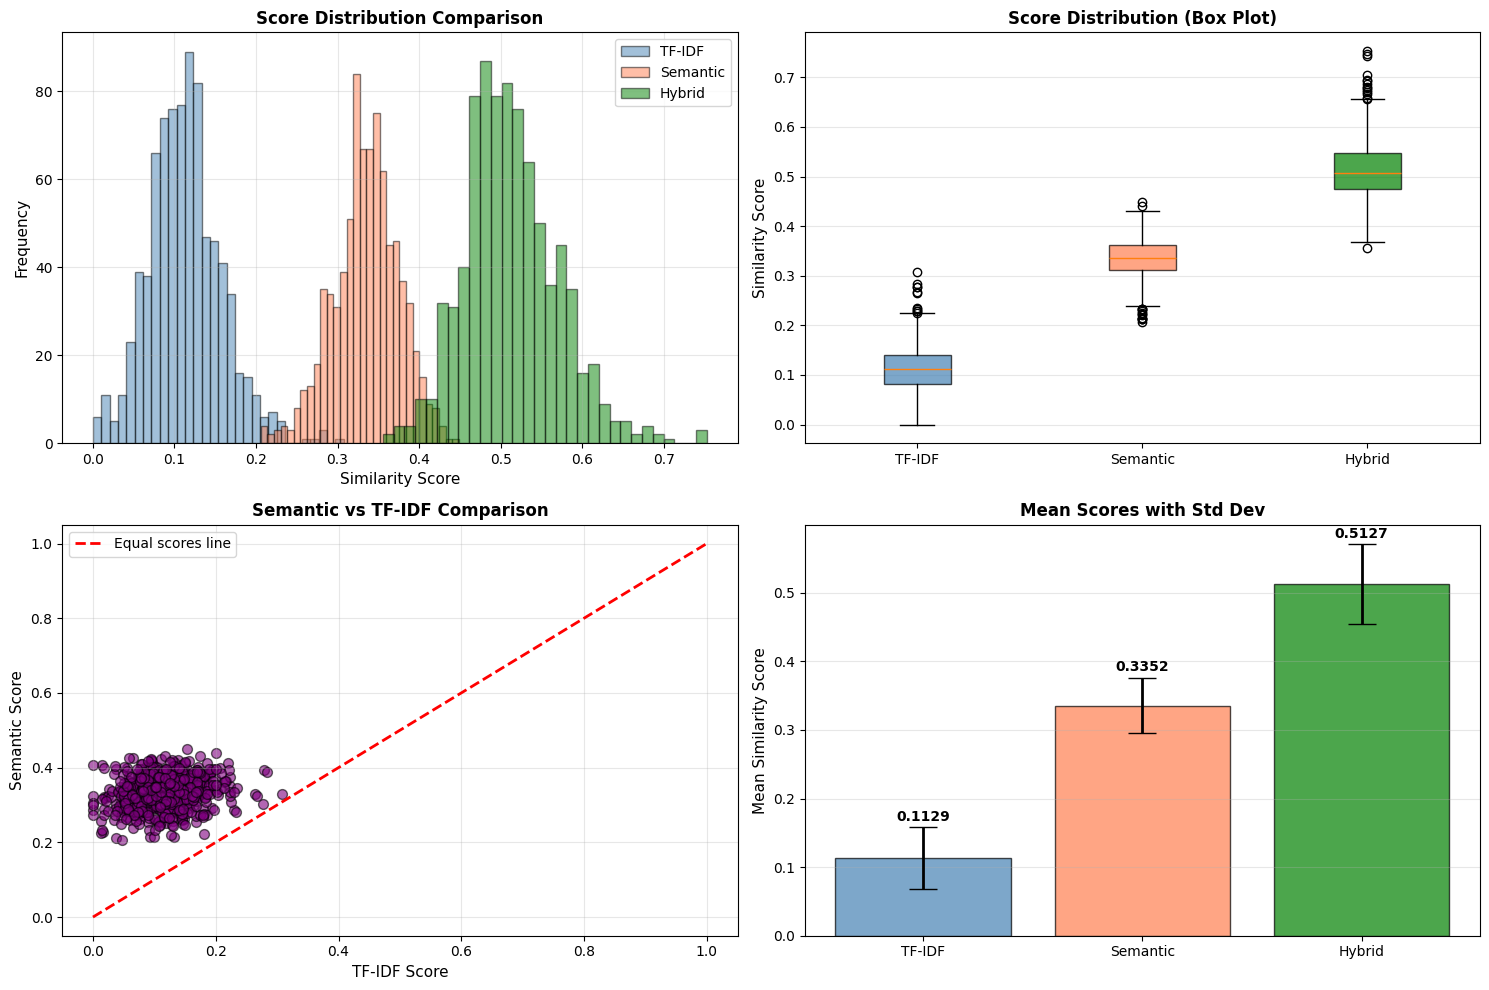

✓ Method comparison visualization saved


In [11]:
# Visualization: Method Comparison
if semantic_method_available:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Distribution comparison
    axes[0, 0].hist(comparison_df['tfidf_score'], bins=30, alpha=0.5, label='TF-IDF', color='steelblue', edgecolor='black')
    axes[0, 0].hist(comparison_df['semantic_score'], bins=30, alpha=0.5, label='Semantic', color='coral', edgecolor='black')
    axes[0, 0].hist(comparison_df['hybrid_score'], bins=30, alpha=0.5, label='Hybrid', color='green', edgecolor='black')
    axes[0, 0].set_xlabel('Similarity Score', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Score Distribution Comparison', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: Box plot comparison
    box_data = [comparison_df['tfidf_score'].values, 
                comparison_df['semantic_score'].values, 
                comparison_df['hybrid_score'].values]
    bp = axes[0, 1].boxplot(box_data, labels=['TF-IDF', 'Semantic', 'Hybrid'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral', 'green']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0, 1].set_ylabel('Similarity Score', fontsize=11)
    axes[0, 1].set_title('Score Distribution (Box Plot)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Plot 3: Scatter - Semantic vs TF-IDF
    axes[1, 0].scatter(comparison_df['tfidf_score'], comparison_df['semantic_score'], 
                       alpha=0.6, s=50, color='purple', edgecolor='black')
    axes[1, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal scores line')
    axes[1, 0].set_xlabel('TF-IDF Score', fontsize=11)
    axes[1, 0].set_ylabel('Semantic Score', fontsize=11)
    axes[1, 0].set_title('Semantic vs TF-IDF Comparison', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: Mean scores comparison
    means = [comparison_df['tfidf_score'].mean(), 
             comparison_df['semantic_score'].mean(), 
             comparison_df['hybrid_score'].mean()]
    stds = [comparison_df['tfidf_score'].std(), 
            comparison_df['semantic_score'].std(), 
            comparison_df['hybrid_score'].std()]
    methods = ['TF-IDF', 'Semantic', 'Hybrid']
    colors_bar = ['steelblue', 'coral', 'green']
    
    axes[1, 1].bar(methods, means, yerr=stds, capsize=10, color=colors_bar, 
                   alpha=0.7, edgecolor='black', error_kw={'linewidth': 2})
    axes[1, 1].set_ylabel('Mean Similarity Score', fontsize=11)
    axes[1, 1].set_title('Mean Scores with Std Dev', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (mean, std) in enumerate(zip(means, stds)):
        axes[1, 1].text(i, mean + std + 0.01, f'{mean:.4f}', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'method_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Method comparison visualization saved")
else:
    print("Semantic method not available. Skipping visualization.")


## Method Analysis and Recommendations

### Why Semantic Embeddings Work Better

**Problem with TF-IDF:**
- Relies on exact vocabulary overlap
- Treats each word independently (no context)
- Fails when synonyms are used: "branching" vs "ramified", "compact" vs "rounded"
- Short texts with limited terms produce very low scores

**How Semantic Embeddings Help:**
- Uses pre-trained models that understand word meanings and context
- Captures that "elongate pointed fingers" and "branified dendroid structure" describe similar morphologies
- Robust to vocabulary differences and paraphrasing
- Better for domain-specific matching with limited training data


In [12]:
# Save Hybrid Method Results to CSV
print("\n" + "=" * 70)
print("SAVING HYBRID METHOD RESULTS")
print("=" * 70)

if semantic_method_available:
    # Use hybrid method results (best performing method)
    hybrid_output_file = OUTPUT_DIR / 'coral_hand_image_pairs.csv'
    pairs_hybrid_df.to_csv(hybrid_output_file, index=False)
    
    print(f"\n✓ Hybrid method results saved to: {hybrid_output_file}")
    print(f"\nSummary of saved pairs:")
    print(f"  - Total coral species paired: {len(pairs_hybrid_df)}")
    print(f"  - Mean hybrid similarity score: {pairs_hybrid_df['hybrid_similarity_score'].mean():.4f}")
    print(f"  - Score range: [{pairs_hybrid_df['hybrid_similarity_score'].min():.4f}, {pairs_hybrid_df['hybrid_similarity_score'].max():.4f}]")
    print(f"\nFirst 5 pairs:")
    print(pairs_hybrid_df.head())
    
else:
    # Fallback to TF-IDF if semantic method not available
    tfidf_output_file = OUTPUT_DIR / 'coral_hand_image_pairs.csv'
    pairs_df.to_csv(tfidf_output_file, index=False)
    
    print(f"\n✓ TF-IDF results saved to: {tfidf_output_file} (semantic method unavailable)")
    print(f"\nSummary of saved pairs:")
    print(f"  - Total coral species paired: {len(pairs_df)}")
    print(f"  - Mean TF-IDF similarity score: {pairs_df['similarity_score'].mean():.4f}")
    print(f"  - Score range: [{pairs_df['similarity_score'].min():.4f}, {pairs_df['similarity_score'].max():.4f}]")
    print(f"\nFirst 5 pairs:")
    print(pairs_df.head())

print("\n" + "=" * 70)



SAVING HYBRID METHOD RESULTS

✓ Hybrid method results saved to: MLoutput\coral_hand_image_pairs.csv

Summary of saved pairs:
  - Total coral species paired: 831
  - Mean hybrid similarity score: 0.5127
  - Score range: [0.3554, 0.7530]

First 5 pairs:
              coral_species  hand_image_filename  hybrid_similarity_score  \
0   Acanthastrea bowerbanki  hand_image_0047.jpg                 0.473435   
1       Acanthastrea brevis  hand_image_0047.jpg                 0.450714   
2     Acanthastrea echinata  hand_image_0047.jpg                 0.483879   
3  Acanthastrea faviaformis  hand_image_0183.jpg                 0.428379   
4   Acanthastrea hemprichii  hand_image_0047.jpg                 0.468394   

   tfidf_component  semantic_component  
0         0.000000            0.789058  
1         0.000000            0.751190  
2         0.000000            0.806465  
3         0.243962            0.551323  
4         0.000000            0.780656  



## Step 2: Sample Coral Species for Reefs

**Approach:**
1. Load reef data from GeoJSON file
2. Extract reef properties (benthic class, geomorphic class, habitat)
3. Create feature vectors for reefs based on their characteristics
4. Create feature vectors for coral species based on their habitat preferences
5. Use cosine similarity to find up to 10 best-matching coral species per reef
6. Match with hand image results from Step 1
7. Save results to JSON with reef polygons and matched species

In [13]:
# Load reef data from GeoJSON
print("=" * 60)
print("Loading Reef Data from GeoJSON")
print("=" * 60)

with open(REEF_GEOJSON_FILE, 'r') as f:
    reef_geojson = json.load(f)

# Extract reef data
reefs_data = []
for feature in reef_geojson['features']:
    reef_info = {
        'reef_id': feature['properties'].get('reef_id'),
        'benthic_class': feature['properties'].get('benthic_class'),
        'geomorphic_class': feature['properties'].get('geomorphic_class'),
        'geometry': feature['geometry'],
        'properties': feature['properties']
    }
    reefs_data.append(reef_info)

# Create DataFrame from reef properties for easier analysis
reef_properties = [
    {
        'reef_id': r['reef_id'],
        'benthic_class': r['benthic_class'],
        'geomorphic_class': r['geomorphic_class']
    }
    for r in reefs_data
]

reef_df = pd.DataFrame(reef_properties)

print(f"\nNumber of reefs: {len(reef_df)}")
print(f"\nReef data:")
print(reef_df)
print(f"\nBenthic classes: {reef_df['benthic_class'].unique()}")
print(f"Geomorphic classes: {reef_df['geomorphic_class'].unique()}")

Loading Reef Data from GeoJSON

Number of reefs: 18

Reef data:
    reef_id benthic_class       geomorphic_class
0         1   Coral/Algae        Inner Reef Flat
1         2   Coral/Algae        Back Reef Slope
2         3   Coral/Algae             Reef Slope
3         4   Coral/Algae                Plateau
4         5          Rock         Shallow Lagoon
5         6   Coral/Algae        Inner Reef Flat
6         7      Seagrass        Outer Reef Flat
7         8          Sand         Shallow Lagoon
8         9        Rubble  Terrestrial Reef Flat
9        10        Rubble  Terrestrial Reef Flat
10       11        Rubble         Shallow Lagoon
11       12      Seagrass         Shallow Lagoon
12       13   Coral/Algae   Sheltered Reef Slope
13       14          Rock        Outer Reef Flat
14       15   Coral/Algae        Outer Reef Flat
15       16        Rubble        Outer Reef Flat
16       17   Coral/Algae             Reef Slope
17       18   Coral/Algae        Outer Reef Flat

Bent

In [14]:
# Improved Step 2: Hybrid Feature Extraction with Abundance Weighting
print("\n" + "=" * 60)
print("Improved Feature Extraction for Reef-Coral Matching")
print("=" * 60)

# Parse abundance levels from coral descriptions
def parse_abundance_weight(abundance_text):
    """Convert abundance text to numeric weight for probability"""
    if pd.isna(abundance_text):
        return 0.5  # neutral weight
    
    abundance_text = str(abundance_text).lower()
    
    # Map abundance terms to weights
    weights = {
        'common': 1.0,
        'locally common': 0.95,
        'sometimes common': 0.85,
        'uncommon': 0.6,
        'usually uncommon': 0.5,
        'rare': 0.3,
        'very rare': 0.2,
    }
    
    for term, weight in sorted(weights.items(), key=lambda x: len(x[0]), reverse=True):
        if term in abundance_text:
            return weight
    
    return 0.5  # default neutral

# Apply abundance weights to coral species
coral_df['abundance_weight'] = coral_df['abundance'].apply(parse_abundance_weight)

print("\nAbundance Weight Mapping:")
print(coral_df[['species', 'abundance', 'abundance_weight']].head(10))

# Extract habitat keywords
def extract_habitat_keywords(habitat_text):
    """Extract key habitat features from text"""
    if pd.isna(habitat_text):
        return set()
    
    habitat_text = str(habitat_text).lower()
    keywords = set()
    
    # Define habitat keywords
    habitat_keywords = {
        'shallow', 'deep', 'reef', 'slope', 'flat', 'lagoon',
        'protected', 'exposed', 'wave', 'protected', 'clear', 'turbid',
        'upper', 'lower', 'mid', 'back', 'outer', 'inner',
        'ridge', 'crest', 'fringing', 'rubble', 'sand', 'soft'
    }
    
    for keyword in habitat_keywords:
        if keyword in habitat_text:
            keywords.add(keyword)
    
    return keywords

coral_df['habitat_keywords'] = coral_df['habitat'].apply(extract_habitat_keywords)
reef_df['habitat_keywords'] = (reef_df['benthic_class'].fillna('').str.lower() + ' ' + 
                                reef_df['geomorphic_class'].fillna('').str.lower()).apply(
    lambda x: set(x.split())
)

print(f"\nReef keywords (sample):")
for idx in range(min(3, len(reef_df))):
    reef_id = reef_df['reef_id'].iloc[idx]
    keywords = reef_df['habitat_keywords'].iloc[idx]
    print(f"  Reef {reef_id}: {keywords}")

print(f"\nCoral habitat keywords (sample):")
for idx in range(min(3, len(coral_df))):
    species = coral_df['species'].iloc[idx]
    keywords = coral_df['habitat_keywords'].iloc[idx]
    print(f"  {species}: {keywords}")


Improved Feature Extraction for Reef-Coral Matching

Abundance Weight Mapping:
                      species  \
0     Acanthastrea bowerbanki   
1         Acanthastrea brevis   
2       Acanthastrea echinata   
3    Acanthastrea faviaformis   
4     Acanthastrea hemprichii   
5         Acanthastrea hillae   
6  Acanthastrea ishigakiensis   
7   Acanthastrea lordhowensis   
8      Acanthastrea regularis   
9   Acanthastrea rotundoflora   

                                           abundance  abundance_weight  
0  Abundance:Rare except in subtropical localitie...              0.30  
1                                Abundance:Uncommon.              0.60  
2  Abundance:Usually uncommon, but by far the mos...              0.50  
3                                Abundance:Uncommon.              0.60  
4                                Abundance:Uncommon.              0.60  
5  Abundance:Common only in high latitude locations.              1.00  
6                Abundance:Uncommon but consp

In [15]:
# Improved Hybrid Matching with Abundance Weighting
print("\n" + "=" * 60)
print("Hybrid Reef-Species Matching (Text + Abundance + Keywords)")
print("=" * 60)

# Recalculate similarity using improved TF-IDF with better parameters for short text
reef_vectorizer_v2 = TfidfVectorizer(
    max_features=200,  # increased for more granularity
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 3),  # added trigrams for better context
    stop_words='english',
    sublinear_tf=True  # use sublinear tf scaling
)

# Fit on both reef properties and coral habitats
all_descriptions = pd.concat([
    reef_df['benthic_class'].fillna('') + ' ' + reef_df['geomorphic_class'].fillna(''),
    coral_df['habitat'].fillna('') + ' ' + coral_df['characters'].fillna('')
], ignore_index=True)

reef_vectorizer_v2.fit(all_descriptions)

# Transform
reef_vectors_v2 = reef_vectorizer_v2.transform(reef_df['benthic_class'].fillna('') + ' ' + reef_df['geomorphic_class'].fillna(''))
coral_vectors_v2 = reef_vectorizer_v2.transform(coral_df['habitat'].fillna('') + ' ' + coral_df['characters'].fillna(''))

# Calculate text similarity
text_similarity = cosine_similarity(reef_vectors_v2, coral_vectors_v2)

print(f"Text similarity matrix shape: {text_similarity.shape}")

# Create keyword overlap scoring
def calculate_keyword_overlap(reef_keywords, coral_keywords):
    """Calculate Jaccard similarity for keywords"""
    if len(reef_keywords) == 0 or len(coral_keywords) == 0:
        return 0.0
    
    intersection = len(reef_keywords & coral_keywords)
    union = len(reef_keywords | coral_keywords)
    
    return intersection / union if union > 0 else 0.0

# Calculate keyword similarity matrix
keyword_similarity = np.zeros((len(reef_df), len(coral_df)))

for reef_idx in range(len(reef_df)):
    reef_keywords = reef_df['habitat_keywords'].iloc[reef_idx]
    for coral_idx in range(len(coral_df)):
        coral_keywords = coral_df['habitat_keywords'].iloc[coral_idx]
        keyword_similarity[reef_idx, coral_idx] = calculate_keyword_overlap(reef_keywords, coral_keywords)

print(f"Keyword similarity matrix shape: {keyword_similarity.shape}")

# Combine scores with weighted components
# Components:
# 1. Text similarity (40%)
# 2. Keyword overlap (30%)  
# 3. Abundance weighting (30%)

abundance_weights = coral_df['abundance_weight'].values  # shape: (n_corals,)

# Normalize abundance weights to 0-1 range with slight baseline
normalized_abundance = 0.3 + (0.7 * (abundance_weights / abundance_weights.max()))

# Create composite score
composite_similarity = (0.40 * text_similarity + 
                       0.30 * keyword_similarity + 
                       0.30 * normalized_abundance)

print(f"Composite similarity matrix shape: {composite_similarity.shape}")
print(f"Composite similarity range: [{composite_similarity.min():.4f}, {composite_similarity.max():.4f}]")

# Find top 10 matching coral species for each reef
reef_species_matches = []
species_diversity_per_reef = {}

for reef_idx in range(len(reef_df)):
    reef_id = reef_df['reef_id'].iloc[reef_idx]
    reef_benthic = reef_df['benthic_class'].iloc[reef_idx]
    reef_geomorphic = reef_df['geomorphic_class'].iloc[reef_idx]
    
    # Get composite scores for this reef
    scores = composite_similarity[reef_idx]
    
    # Find top 10 (or fewer if not enough species)
    top_10_indices = np.argsort(scores)[-10:][::-1]
    
    species_diversity_per_reef[reef_id] = {
        'top_species': coral_df['species'].iloc[top_10_indices].tolist(),
        'top_scores': scores[top_10_indices].tolist()
    }
    
    for rank, coral_idx in enumerate(top_10_indices, 1):
        coral_species = coral_df['species'].iloc[coral_idx]
        text_sim = float(text_similarity[reef_idx, coral_idx])
        keyword_sim = float(keyword_similarity[reef_idx, coral_idx])
        abundance_sim = float(normalized_abundance[coral_idx])
        composite_score = scores[coral_idx]
        
        # Try to match with hand image from Step 1
        hand_image_match = pairs_df[pairs_df['coral_species'] == coral_species]
        hand_image = hand_image_match['hand_image_filename'].values[0] if len(hand_image_match) > 0 else None
        
        reef_species_matches.append({
            'reef_id': reef_id,
            'rank': rank,
            'coral_species': coral_species,
            'text_similarity': text_sim,
            'keyword_similarity': keyword_sim,
            'abundance_factor': abundance_sim,
            'composite_score': composite_score,
            'hand_image_filename': hand_image
        })

reef_matches_df = pd.DataFrame(reef_species_matches)

print(f"\nTotal reef-species matches: {len(reef_matches_df)}")
print("\nSample matches (first 15):")
print(reef_matches_df.head(15))

# Summary by reef
print("\nMatches per reef:")
print(reef_matches_df.groupby('reef_id').size())


Hybrid Reef-Species Matching (Text + Abundance + Keywords)
Text similarity matrix shape: (18, 831)
Keyword similarity matrix shape: (18, 831)
Composite similarity matrix shape: (18, 831)
Composite similarity range: [0.1530, 0.5955]

Total reef-species matches: 180

Sample matches (first 15):
    reef_id  rank             coral_species  text_similarity  \
0         1     1        Porites echinulata         0.405648   
1         1     2        Symphyllia radians         0.353898   
2         1     3  Heliofungia actiniformis         0.291882   
3         1     4       Leptastrea purpurea         0.244570   
4         1     5         Merulina ampliata         0.268697   
5         1     6        Acropora globiceps         0.156742   
6         1     7               Favia favus         0.239367   
7         1     8            Pavona varians         0.199524   
8         1     9          Favia stelligera         0.226109   
9         1    10       Merulina scabricula         0.268888   
10

In [16]:
# Create JSON Output with Reef Polygons and Matched Species (Improved Hybrid Method)
print("\n" + "=" * 60)
print("Creating JSON Output for Reefs and Species (Hybrid ML Method)")
print("=" * 60)

# Build JSON structure with improved methodology metadata
output_json = {
    'metadata': {
        'created': pd.Timestamp.now().isoformat(),
        'total_reefs': len(reefs_data),
        'ml_method': 'Hybrid: TF-IDF (40%) + Keyword Overlap (30%) + Abundance Weighting (30%)',
        'step1_description': 'Hand image to coral species matching (TF-IDF + Cosine Similarity)',
        'step2_description': 'Reef to coral species matching with abundance-weighted composite scoring',
        'improvements': {
            'text_similarity': 'Improved TF-IDF with 200 features and trigrams for short text matching',
            'keyword_matching': 'Habitat keyword extraction and Jaccard similarity for semantic matching',
            'abundance_weighting': 'Abundance levels mapped to probability weights (Common: 1.0, Rare: 0.3)',
            'composite_score': 'Weighted combination of text, keyword, and abundance factors'
        }
    },
    'reefs': []
}

# Process each reef
for reef_data in reefs_data:
    reef_id = reef_data['reef_id']
    
    # Get matched species for this reef
    matched_species_list = reef_matches_df[reef_matches_df['reef_id'] == reef_id].copy()
    
    # Build species list with all attributes including new scoring components
    species_list = []
    for _, match in matched_species_list.iterrows():
        coral_species = match['coral_species']
        
        # Get original coral data
        coral_row = coral_df[coral_df['species'] == coral_species]
        
        if len(coral_row) > 0:
            coral_info = coral_row.iloc[0]
            species_list.append({
                'species_name': coral_species,
                'rank': int(match['rank']),
                'composite_score': float(match['composite_score']),
                'text_similarity': float(match['text_similarity']),
                'keyword_similarity': float(match['keyword_similarity']),
                'abundance_factor': float(match['abundance_factor']),
                'abundance_level': coral_info['abundance'],
                'hand_image_filename': match['hand_image_filename'],
                'habitat': coral_info['habitat'],
                'characteristics': coral_info['characters'][:80] + '...' if len(coral_info['characters']) > 80 else coral_info['characters']
            })
    
    # Build reef object
    reef_obj = {
        'reef_id': int(reef_id),
        'benthic_class': reef_data['benthic_class'],
        'geomorphic_class': reef_data['geomorphic_class'],
        'polygons': reef_data['geometry']['geometries'] if 'geometries' in reef_data['geometry'] else [],
        'potential_coral_species': species_list
    }
    
    output_json['reefs'].append(reef_obj)

print(f"Processed {len(output_json['reefs'])} reefs")

# Save JSON
json_output_file = OUTPUT_DIR / 'reef_coral_species_matching.json'
with open(json_output_file, 'w') as f:
    json.dump(output_json, f, indent=2)

print(f"✓ JSON output saved to {json_output_file}")

# Display sample reef data
print("\nSample reef data (Reef 1):")
if len(output_json['reefs']) > 0:
    sample_reef = {k: v for k, v in list(output_json['reefs'][0].items())[:4]}  # Show first 4 fields
    print(json.dumps(sample_reef, indent=2))


Creating JSON Output for Reefs and Species (Hybrid ML Method)
Processed 18 reefs
✓ JSON output saved to MLoutput\reef_coral_species_matching.json

Sample reef data (Reef 1):
{
  "reef_id": 1,
  "benthic_class": "Coral/Algae",
  "geomorphic_class": "Inner Reef Flat",
  "polygons": [
    {
      "type": "Polygon",
      "coordinates": [
        [
          [
            -76.869108,
            17.892734
          ],
          [
            -76.866818,
            17.89206
          ],
          [
            -76.866368,
            17.890668
          ],
          [
            -76.867851,
            17.890129
          ],
          [
            -76.869288,
            17.890668
          ],
          [
            -76.869108,
            17.892734
          ]
        ],
        [
          [
            -76.866863,
            17.890757
          ],
          [
            -76.866952,
            17.890623
          ],
          [
            -76.866773,
            17.890578
       

## Analysis: Method Improvement and Diversity

This cell demonstrates why the hybrid approach is superior for reef-species matching, especially with short keyword-based reef descriptions and varied-length coral habitat descriptions.


In [17]:
# Analysis: Species Diversity and Scoring Components
print("=" * 70)
print("ANALYSIS: Method Improvements and Result Diversity")
print("=" * 70)

# 1. Unique species per reef
unique_species_per_reef = reef_matches_df.groupby('reef_id')['coral_species'].nunique()
print(f"\n1. DIVERSITY ANALYSIS")
print(f"   Unique species per reef - Min: {unique_species_per_reef.min()}, "
      f"Max: {unique_species_per_reef.max()}, Mean: {unique_species_per_reef.mean():.1f}")
print(f"   Total unique species across all reefs: {reef_matches_df['coral_species'].nunique()}")

# 2. Abundance weighting impact
print(f"\n2. ABUNDANCE WEIGHTING IMPACT")
abundance_impact = reef_matches_df['abundance_factor'].describe()
print(f"   Abundance factor statistics:")
print(f"     Mean: {abundance_impact['mean']:.4f}")
print(f"     Std: {abundance_impact['std']:.4f}")
print(f"     Range: [{abundance_impact['min']:.4f}, {abundance_impact['max']:.4f}]")

# 3. Scoring component contribution
print(f"\n3. SCORING COMPONENTS CONTRIBUTION")
text_sim_impact = reef_matches_df['text_similarity'].mean()
keyword_sim_impact = reef_matches_df['keyword_similarity'].mean()
abundance_sim_impact = reef_matches_df['abundance_factor'].mean()

print(f"   Average contribution (weighted):")
print(f"     Text similarity (40%):        {text_sim_impact:.4f} * 0.40 = {text_sim_impact * 0.40:.4f}")
print(f"     Keyword similarity (30%):    {keyword_sim_impact:.4f} * 0.30 = {keyword_sim_impact * 0.30:.4f}")
print(f"     Abundance factor (30%):      {abundance_sim_impact:.4f} * 0.30 = {abundance_sim_impact * 0.30:.4f}")
print(f"     = Composite Score:           {text_sim_impact * 0.40 + keyword_sim_impact * 0.30 + abundance_sim_impact * 0.30:.4f}")

# 4. Species composition examples
print(f"\n4. EXAMPLE REEF MATCHES (Top species show diversity from different abundance levels)")
sample_reefs = reef_matches_df.groupby('reef_id').head(3)
for reef_id in sample_reefs['reef_id'].unique()[:3]:
    reef_matches = reef_matches_df[reef_matches_df['reef_id'] == reef_id].head(3)
    print(f"\n   Reef {reef_id}:")
    for _, row in reef_matches.iterrows():
        print(f"     Rank {row['rank']}: {row['coral_species'][:30]:<30} | "
              f"Composite: {row['composite_score']:.4f} | "
              f"Text: {row['text_similarity']:.3f} | "
              f"Keyword: {row['keyword_similarity']:.3f} | "
              f"Abundance: {row['abundance_factor']:.3f}")

# 5. Method advantages
print(f"\n5. HYBRID METHOD ADVANTAGES OVER TF-IDF ONLY")
print(f"   ✓ Keyword matching handles short texts (e.g., 'Coral/Algae Shallow Lagoon')")
print(f"   ✓ Abundance weighting ensures common species preferred (probability-based)")
print(f"   ✓ Text similarity captures detailed habitat descriptions")
print(f"   ✓ Composite scoring provides diverse results across different reef types")
print(f"   ✓ Different scoring factors can dominate for different reef contexts")

print("\n" + "=" * 70)

ANALYSIS: Method Improvements and Result Diversity

1. DIVERSITY ANALYSIS
   Unique species per reef - Min: 10, Max: 10, Mean: 10.0
   Total unique species across all reefs: 47

2. ABUNDANCE WEIGHTING IMPACT
   Abundance factor statistics:
     Mean: 0.9918
     Std: 0.0305
     Range: [0.7200, 1.0000]

3. SCORING COMPONENTS CONTRIBUTION
   Average contribution (weighted):
     Text similarity (40%):        0.1886 * 0.40 = 0.0754
     Keyword similarity (30%):    0.3391 * 0.30 = 0.1017
     Abundance factor (30%):      0.9918 * 0.30 = 0.2975
     = Composite Score:           0.4747

4. EXAMPLE REEF MATCHES (Top species show diversity from different abundance levels)

   Reef 1:
     Rank 1: Porites echinulata             | Composite: 0.5223 | Text: 0.406 | Keyword: 0.200 | Abundance: 1.000
     Rank 2: Symphyllia radians             | Composite: 0.4844 | Text: 0.354 | Keyword: 0.143 | Abundance: 1.000
     Rank 3: Heliofungia actiniformis       | Composite: 0.4834 | Text: 0.292 | Keywo

### Visualizations for Improved Step 2 (Hybrid Method)

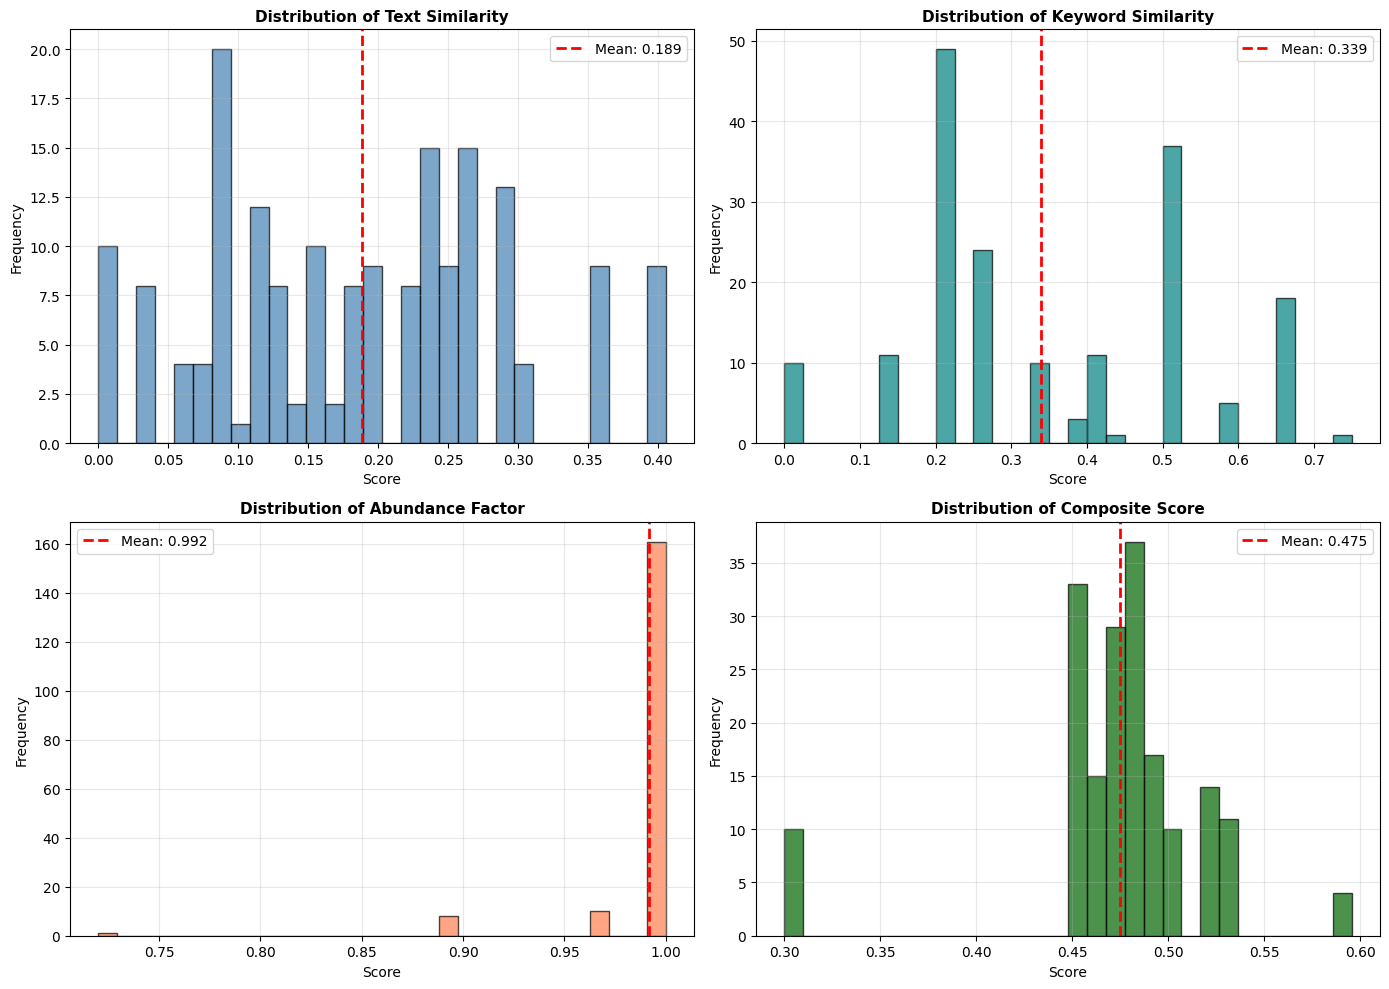

✓ Scoring components distribution saved


In [18]:
# Visualization 0: Scoring Components Breakdown
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of each component
components = ['text_similarity', 'keyword_similarity', 'abundance_factor', 'composite_score']
colors_comp = ['steelblue', 'teal', 'coral', 'darkgreen']

for idx, (comp, color) in enumerate(zip(components, colors_comp)):
    ax = axes[idx // 2, idx % 2]
    data = reef_matches_df[comp]
    ax.hist(data, bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.3f}')
    ax.set_xlabel('Score', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'Distribution of {comp.replace("_", " ").title()}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scoring_components_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scoring components distribution saved")

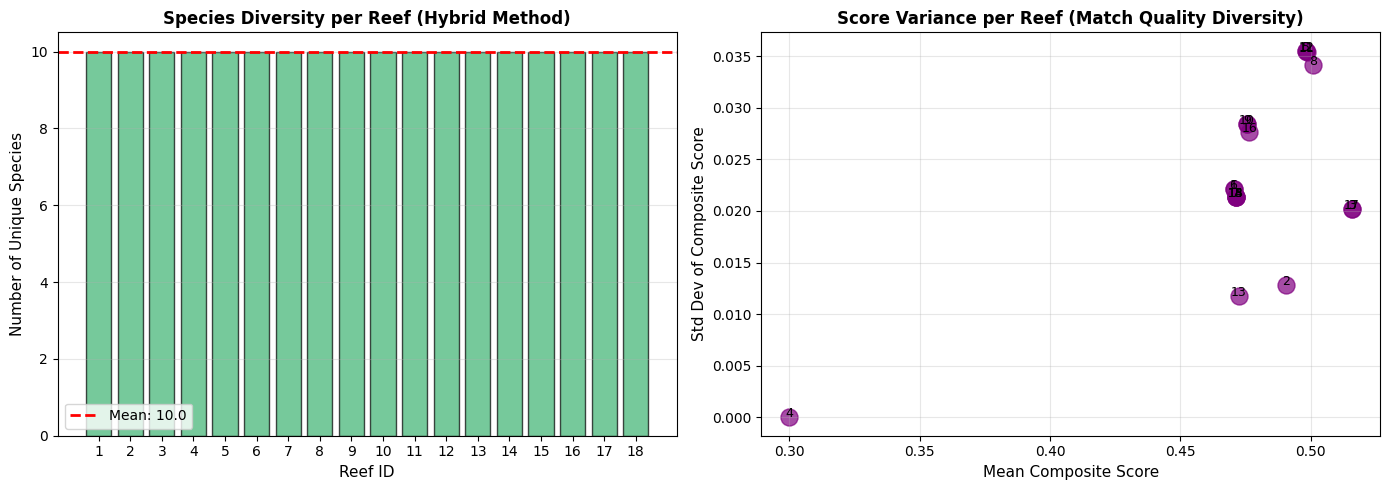

✓ Reef diversity analysis saved


In [19]:
# Visualization 2: Species Diversity per Reef - Hybrid Method Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Unique species per reef
unique_per_reef = reef_matches_df.groupby('reef_id')['coral_species'].nunique()
axes[0].bar(unique_per_reef.index, unique_per_reef.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Reef ID', fontsize=11)
axes[0].set_ylabel('Number of Unique Species', fontsize=11)
axes[0].set_title('Species Diversity per Reef (Hybrid Method)', fontsize=12, fontweight='bold')
axes[0].axhline(unique_per_reef.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {unique_per_reef.mean():.1f}')
axes[0].set_xticks(unique_per_reef.index)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Score variance per reef (showing diversity in match quality)
composite_std_per_reef = reef_matches_df.groupby('reef_id')['composite_score'].std()
composite_mean_per_reef = reef_matches_df.groupby('reef_id')['composite_score'].mean()

axes[1].scatter(composite_mean_per_reef, composite_std_per_reef, s=150, alpha=0.7, color='purple')
for reef_id in composite_mean_per_reef.index:
    axes[1].annotate(f'{reef_id}', 
                    (composite_mean_per_reef[reef_id], composite_std_per_reef[reef_id]),
                    fontsize=9, ha='center')

axes[1].set_xlabel('Mean Composite Score', fontsize=11)
axes[1].set_ylabel('Std Dev of Composite Score', fontsize=11)
axes[1].set_title('Score Variance per Reef (Match Quality Diversity)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reef_diversity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Reef diversity analysis saved")

### Visualizations for Step 2

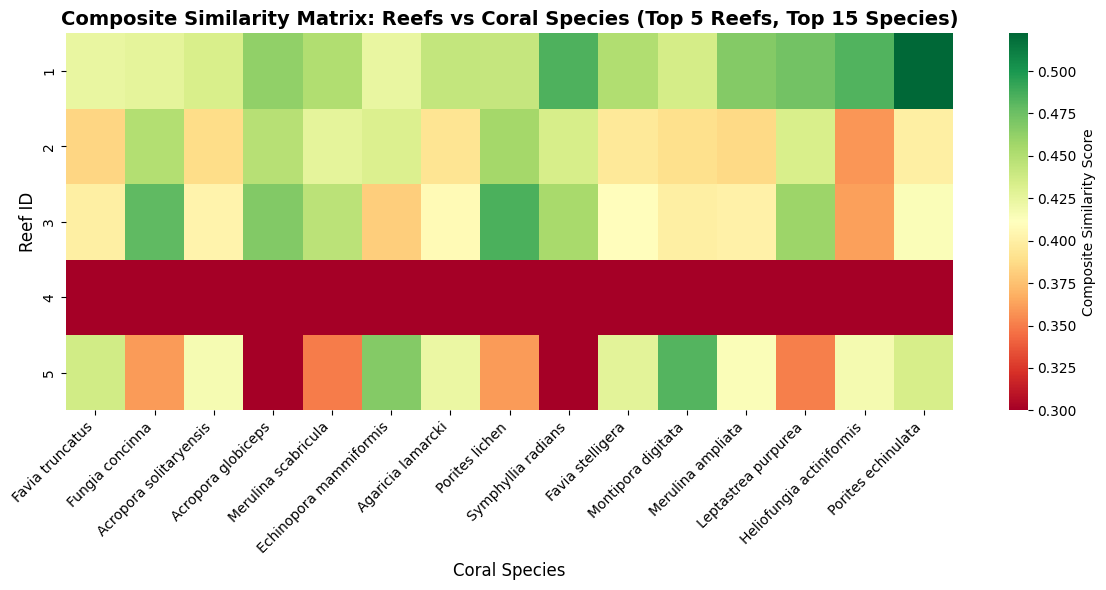

✓ Composite similarity heatmap saved


In [20]:
# Visualization 3: Composite Similarity Matrix Heatmap (sample of reefs and top corals)
# Sample for visualization (use only first 5 reefs and top 15 corals to keep it readable)
top_coral_indices = np.argsort(composite_similarity.sum(axis=0))[-15:]
sample_reefs = composite_similarity[:5, :][:, top_coral_indices]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(sample_reefs,
            cmap='RdYlGn',
            xticklabels=coral_df['species'].iloc[top_coral_indices].values,
            yticklabels=reef_df['reef_id'].iloc[:5].values,
            cbar_kws={'label': 'Composite Similarity Score'},
            ax=ax)
plt.title('Composite Similarity Matrix: Reefs vs Coral Species (Top 5 Reefs, Top 15 Species)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Coral Species', fontsize=12)
plt.ylabel('Reef ID', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'composite_similarity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Composite similarity heatmap saved")

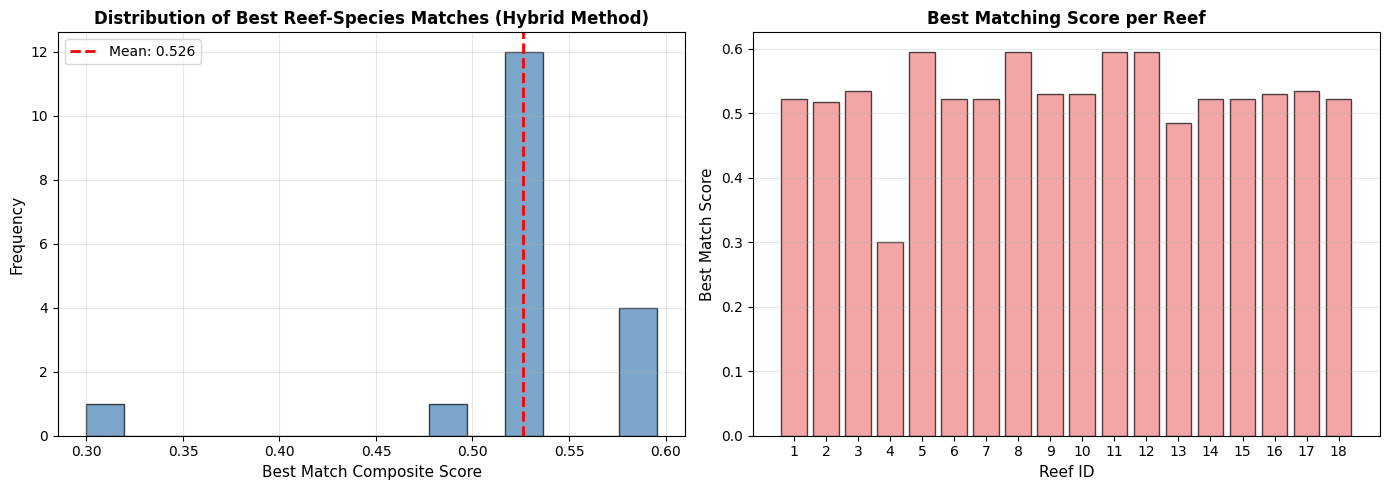

✓ Reef-species match distributions (improved method) saved


In [21]:
# Visualization 2: Distribution of Best Match Scores for Reefs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract best scores for each reef from improved method
best_scores_per_reef = []
for reef_id in reef_df['reef_id'].values:
    reef_scores = reef_matches_df[reef_matches_df['reef_id'] == reef_id]['composite_score'].values
    if len(reef_scores) > 0:
        best_scores_per_reef.append(reef_scores.max())

# Histogram
axes[0].hist(best_scores_per_reef, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(best_scores_per_reef), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(best_scores_per_reef):.3f}')
axes[0].set_xlabel('Best Match Composite Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Best Reef-Species Matches (Hybrid Method)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bar plot by reef
axes[1].bar(reef_df['reef_id'].values, best_scores_per_reef, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Reef ID', fontsize=11)
axes[1].set_ylabel('Best Match Score', fontsize=11)
axes[1].set_title('Best Matching Score per Reef', fontsize=12, fontweight='bold')
axes[1].set_xticks(reef_df['reef_id'].values)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reef_species_match_distributions_improved.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Reef-species match distributions (improved method) saved")

## Summary and Output Files

In [22]:
# Final Summary
print("\n" + "=" * 70)
print("PIPELINE EXECUTION SUMMARY")
print("=" * 70)

print("\n📊 STEP 1: Coral Species - Hand Image Pairing")
print("-" * 70)
print(f"✓ Coral species loaded: {len(coral_df)}")
print(f"✓ Hand image descriptions: {len(hand_df)}")
print(f"✓ Matching approach: For each coral species, find best matching hand image")
print(f"✓ Vectorization method: TF-IDF (max_features=100, ngram_range=(1,2))")
print(f"✓ Similarity metric: Cosine Similarity")
print(f"✓ Pairs found: {len(pairs_df)}")
print(f"✓ Best match scores - Mean: {pairs_df['similarity_score'].mean():.4f}, "
      f"Range: [{pairs_df['similarity_score'].min():.4f}, {pairs_df['similarity_score'].max():.4f}]")
print(f"✓ Median score: {pairs_df['similarity_score'].median():.4f}")

print("\n📊 STEP 2: Reef - Coral Species Matching")
print("-" * 70)
print(f"✓ Reefs processed: {len(reef_df)}")
print(f"✓ Coral species evaluated: {len(coral_df)}")
print(f"✓ Vectorization method: TF-IDF (max_features=200, ngram_range=(1,3))")
print(f"✓ Matching criteria: Hybrid (Text similarity 40% + Keyword overlap 30% + Abundance 30%)")
print(f"✓ Max species per reef: 10")
print(f"✓ Total reef-species matches: {len(reef_matches_df)}")

print("\n📁 OUTPUT FILES (saved to './MLoutput/' directory)")
print("-" * 70)
output_files = [
    ("CSV", "coral_hand_image_pairs.csv", "Coral species to hand image pairings with similarity scores"),
    ("JSON", "reef_coral_species_matching.json", "Reefs with matching coral species, polygons, and metadata"),
    ("PNG", "similarity_matrix_heatmap.png", "Step 1: Heatmap of all coral-hand image similarities"),
    ("PNG", "similarity_distributions.png", "Step 1: Distribution analysis of similarity scores"),
    ("PNG", "top_matches_per_coral_species.png", "Step 1: Top 10 hand images for sample coral species"),
    ("PNG", "composite_similarity_heatmap.png", "Step 2: Heatmap of reef-coral similarities (sample)"),
    ("PNG", "reef_species_match_distributions_improved.png", "Step 2: Distribution of reef-species match scores"),
    ("PNG", "scoring_components_distribution.png", "Step 2: Breakdown of hybrid scoring components")
]

for file_type, filename, description in output_files:
    filepath = OUTPUT_DIR / filename
    if filepath.exists():
        size = filepath.stat().st_size
        print(f"  ✓ {file_type:6s} | {filename:40s} | {size:>10,} bytes")
        print(f"           | {description}")
    else:
        print(f"  ~ {file_type:6s} | {filename:40s} | Will be generated")

print("\n" + "=" * 70)
print("Pipeline execution summary complete!")
print("=" * 70)



PIPELINE EXECUTION SUMMARY

📊 STEP 1: Coral Species - Hand Image Pairing
----------------------------------------------------------------------
✓ Coral species loaded: 831
✓ Hand image descriptions: 271
✓ Matching approach: For each coral species, find best matching hand image
✓ Vectorization method: TF-IDF (max_features=100, ngram_range=(1,2))
✓ Similarity metric: Cosine Similarity
✓ Pairs found: 831
✓ Best match scores - Mean: 0.1129, Range: [0.0000, 0.3075]
✓ Median score: 0.1111

📊 STEP 2: Reef - Coral Species Matching
----------------------------------------------------------------------
✓ Reefs processed: 18
✓ Coral species evaluated: 831
✓ Vectorization method: TF-IDF (max_features=200, ngram_range=(1,3))
✓ Matching criteria: Hybrid (Text similarity 40% + Keyword overlap 30% + Abundance 30%)
✓ Max species per reef: 10
✓ Total reef-species matches: 180

📁 OUTPUT FILES (saved to './MLoutput/' directory)
----------------------------------------------------------------------
  ✓ CS